In [ ]:
!pip install ultralytics -q
print('Done!')

Done!


In [ ]:
import zipfile, os

os.makedirs('/content/raw/cvat_mango', exist_ok=True)
os.makedirs('/content/raw/cvat_tea', exist_ok=True)
os.makedirs('/content/raw/roboflow_mango', exist_ok=True)
os.makedirs('/content/raw/roboflow_tea', exist_ok=True)

print('Extracting CVAT mango...')
with zipfile.ZipFile('/teamspace/studios/this_studio/cropmango (1).zip', 'r') as z:
    z.extractall('/content/raw/cvat_mango')

print('Extracting CVAT tea...')
with zipfile.ZipFile('/teamspace/studios/this_studio/croptea (1).zip', 'r') as z:
    z.extractall('/content/raw/cvat_tea')

print('Extracting Roboflow mango...')
with zipfile.ZipFile('/teamspace/studios/this_studio/roboflowmango.zip', 'r') as z:
    z.extractall('/content/raw/roboflow_mango')

print('Extracting Roboflow tea...')
with zipfile.ZipFile('/teamspace/studios/this_studio/tea_roboflow.zip', 'r') as z:
    z.extractall('/content/raw/roboflow_tea')

print('All extracted!')

Extracting CVAT mango...
Extracting CVAT tea...
Extracting Roboflow mango...
Extracting Roboflow tea...
All extracted!


In [ ]:
import os

def count_files(path):
    for root, dirs, files in os.walk(path):
        img_files = [f for f in files if f.lower().endswith(('.jpg','.jpeg','.png'))]
        txt_files = [f for f in files if f.endswith('.txt')]
        if img_files or txt_files:
            print(f'{root}/')
            if img_files: print(f'  📷 {len(img_files)} images')
            if txt_files: print(f'  📝 {len(txt_files)} labels')

count_files('/content/raw')

/content/raw/cvat_mango/
  📝 1 labels
/content/raw/cvat_mango/labels/train/
  📝 549 labels
/content/raw/cvat_mango/images/train/
  📷 549 images
/content/raw/cvat_tea/
  📝 1 labels
/content/raw/cvat_tea/labels/train/
  📝 726 labels
/content/raw/cvat_tea/images/train/
  📷 728 images
/content/raw/roboflow_tea/tea_roboflow/train/labels/
  📝 663 labels
/content/raw/roboflow_tea/tea_roboflow/train/images/
  📷 663 images
/content/raw/roboflow_mango/roboflowmango/labels/
  📝 1200 labels
/content/raw/roboflow_mango/roboflowmango/images/
  📷 1200 images


In [ ]:
from ultralytics import SAM
import cv2, shutil
from pathlib import Path

sam_model = SAM('sam2.1_b.pt')

IMG_DIR = '/content/raw/roboflow_mango/roboflowmango/images'
LBL_DIR = '/content/raw/roboflow_mango/roboflowmango/labels'
OUT_IMG = '/content/raw/mango_sam/images'
OUT_LBL = '/content/raw/mango_sam/labels'

Path(OUT_IMG).mkdir(parents=True, exist_ok=True)
Path(OUT_LBL).mkdir(parents=True, exist_ok=True)

images = list(Path(IMG_DIR).glob('*.*'))
print(f'Total mango images to convert: {len(images)}')

success = 0
failed = 0

for i, img_path in enumerate(images):
    lbl_path = Path(LBL_DIR) / (img_path.stem + '.txt')
    if not lbl_path.exists():
        failed += 1
        continue
    img = cv2.imread(str(img_path))
    if img is None:
        failed += 1
        continue
    h, w = img.shape[:2]
    boxes = []
    with open(lbl_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                cls, cx, cy, bw, bh = map(float, parts)
                x1 = (cx - bw/2) * w
                y1 = (cy - bh/2) * h
                x2 = (cx + bw/2) * w
                y2 = (cy + bh/2) * h
                boxes.append([x1, y1, x2, y2])
    if not boxes:
        failed += 1
        continue
    try:
        results = sam_model(str(img_path), bboxes=boxes, verbose=False)
        seg_lines = []
        for result in results:
            if result.masks is None:
                continue
            for mask in result.masks.xy:
                coords = mask.flatten()
                norm = []
                for j, c in enumerate(coords):
                    norm.append(c/w if j%2==0 else c/h)
                coord_str = ' '.join([f'{x:.6f}' for x in norm])
                seg_lines.append(f'0 {coord_str}')
        if seg_lines:
            shutil.copy(img_path, f'{OUT_IMG}/{img_path.name}')
            with open(f'{OUT_LBL}/{img_path.stem}.txt', 'w') as f:
                f.write('\n'.join(seg_lines))
            success += 1
        else:
            failed += 1
    except:
        failed += 1
    if (i+1) % 100 == 0:
        print(f'Progress: {i+1}/{len(images)} | ✅ {success} | ❌ {failed}')

print(f'\n✅ Done! Success: {success} | Failed: {failed}')

Total mango images to convert: 1200
Progress: 100/1200 | ✅ 99 | ❌ 1
Progress: 200/1200 | ✅ 198 | ❌ 2
Progress: 300/1200 | ✅ 298 | ❌ 2
Progress: 400/1200 | ✅ 397 | ❌ 3
Progress: 500/1200 | ✅ 497 | ❌ 3
Progress: 600/1200 | ✅ 597 | ❌ 3
Progress: 700/1200 | ✅ 697 | ❌ 3
Progress: 800/1200 | ✅ 796 | ❌ 4
Progress: 900/1200 | ✅ 896 | ❌ 4
Progress: 1000/1200 | ✅ 996 | ❌ 4
Progress: 1100/1200 | ✅ 1096 | ❌ 4
Progress: 1200/1200 | ✅ 1196 | ❌ 4

✅ Done! Success: 1196 | Failed: 4


In [ ]:
import os, shutil, random
from pathlib import Path

random.seed(42)

OUTPUT = '/content/dataset'
for split in ['train', 'val', 'test']:
    Path(f'{OUTPUT}/images/{split}').mkdir(parents=True, exist_ok=True)
    Path(f'{OUTPUT}/labels/{split}').mkdir(parents=True, exist_ok=True)

def copy_with_class(img_path, lbl_path, split, new_class):
    dst_img = f'{OUTPUT}/images/{split}/{img_path.name}'
    shutil.copy2(img_path, dst_img)
    dst_lbl = f'{OUTPUT}/labels/{split}/{img_path.stem}.txt'
    lines = Path(lbl_path).read_text().strip().splitlines()
    fixed = []
    for line in lines:
        parts = line.split()
        if parts:
            parts[0] = str(new_class)
            fixed.append(' '.join(parts))
    Path(dst_lbl).write_text('\n'.join(fixed))

def process_dataset(img_dir, lbl_dir, new_class, val_ratio=0.15, test_ratio=0.15):
    imgs = list(Path(img_dir).glob('*.*'))
    imgs = [i for i in imgs if i.suffix.lower() in ['.jpg','.jpeg','.png']]
    random.shuffle(imgs)
    n_test = int(len(imgs) * test_ratio)
    n_val = int(len(imgs) * val_ratio)
    test_imgs = set(i.name for i in imgs[:n_test])
    val_imgs = set(i.name for i in imgs[n_test:n_test+n_val])
    added = 0
    for img in imgs:
        lbl = Path(lbl_dir) / (img.stem + '.txt')
        if not lbl.exists():
            continue
        if img.name in test_imgs:
            split = 'test'
        elif img.name in val_imgs:
            split = 'val'
        else:
            split = 'train'
        copy_with_class(img, lbl, split, new_class)
        added += 1
    return added

n = process_dataset(
    '/content/raw/cvat_mango/images/train',
    '/content/raw/cvat_mango/labels/train',
    new_class=0)
print(f'CVAT Mango: {n} images')

n = process_dataset(
    '/content/raw/mango_sam/images',
    '/content/raw/mango_sam/labels',
    new_class=0)
print(f'SAM2 Mango: {n} images')

n = process_dataset(
    '/content/raw/cvat_tea/images/train',
    '/content/raw/cvat_tea/labels/train',
    new_class=1)
print(f'CVAT Tea: {n} images')

n = process_dataset(
    '/content/raw/roboflow_tea/tea_roboflow/train/images',
    '/content/raw/roboflow_tea/tea_roboflow/train/labels',
    new_class=1)
print(f'Roboflow Tea: {n} images')

for split in ['train', 'val', 'test']:
    imgs = len(list(Path(f'{OUTPUT}/images/{split}').glob('*.*')))
    lbls = len(list(Path(f'{OUTPUT}/labels/{split}').glob('*.txt')))
    print(f'  {split}: {imgs} images, {lbls} labels')

total = sum(len(list(Path(f'{OUTPUT}/images/{s}').glob('*.*'))) for s in ['train','val','test'])
print(f'\nTotal: {total} images')

CVAT Mango: 549 images
SAM2 Mango: 1196 images
CVAT Tea: 726 images
Roboflow Tea: 663 images
  train: 2196 images, 2196 labels
  val: 469 images, 469 labels
  test: 469 images, 469 labels

Total: 3134 images


In [ ]:
yaml_content = """path: /content/dataset
train: images/train
val: images/val
test: images/test
nc: 2
names: ['mango', 'tea']
"""

with open('/content/dataset/data.yaml', 'w') as f:
    f.write(yaml_content)

print('data.yaml created!')

data.yaml created!


In [ ]:
from pathlib import Path
from collections import Counter

class_counts = Counter()

for lbl_file in Path('/content/dataset').rglob('labels/*/*.txt'):
    for line in lbl_file.read_text().strip().splitlines():
        if line.strip():
            cls = int(line.split()[0])
            class_counts[cls] += 1

print(f'  Class 0 (mango): {class_counts[0]} annotations')
print(f'  Class 1 (tea):   {class_counts[1]} annotations')
unexpected = [c for c in class_counts if c not in [0, 1]]
if unexpected:
    print(f'⚠️ Unexpected: {unexpected}')
else:
    print('All labels correct!')

  Class 0 (mango): 2314 annotations
  Class 1 (tea):   6400 annotations
All labels correct!


In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8l-seg.pt')

model.train(
    data='/content/dataset/data.yaml',
    epochs=45,
    imgsz=800,
    batch=4,
    device=0,
    patience=30,
    save_period=10,
    project='/content/runs',
    name='mango_tea_seg',
    optimizer='AdamW',
    lr0=0.001,
    lrf=0.00001,
    warmup_epochs=3,
    weight_decay=0.0005,
    flipud=0.3,
    fliplr=0.5,
    hsv_h=0.02,
    hsv_s=0.8,
    hsv_v=0.5,
    mosaic=1.0,
    degrees=10.0,
    translate=0.1,
    scale=0.5,
    cos_lr=True,
    exist_ok=Truengine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/dataset/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=45, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.3, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02, hsv_s=0.8, hsv_v=0.5, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=1e-05, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8l-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=mango_tea_seg, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=30, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False, project=/content/runs, rect=False, resume=False, retina_masks=False, rle=1.0, save=True, save_conf=False, save_crop=False, save_dir=/content/runs/mango_tea_seg, save_frames=False, save_json=False, save_period=10, save_txt=False, scale=0.5, seed=0, shear=0.0, show=False, show_boxes=True, show_conf=True, show_labels=True, simplify=True, single_cls=False, source=None, split=val, stream_buffer=False, task=segment, time=None, tracker=botsort.yaml, translate=0.1, val=True, verbose=True, vid_stride=1, visualize=False, warmup_bias_lr=0.1, warmup_epochs=3, warmup_momentum=0.8, weight_decay=0.0005, workers=8, workspace=None
e,
)
print('Training done!')

Ultralytics 8.4.56 🚀 Python-3.10.10 torch-2.1.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/dataset/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=45, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.3, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02, hsv_s=0.8, hsv_v=0.5, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=1e-05, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8l-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=mango_tea_seg, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience

In [ ]:
from ultralytics import YOLO

model = YOLO('/content/runs/mango_tea_seg/weights/best.pt')

metrics = model.val(
    data='/content/dataset/data.yaml',
    split='test',
    imgsz=800,
    batch=4,
    device=0,
)

print('\nTest Results:')
print(f'  mAP50 (Box)  : {metrics.box.map50:.4f}')
print(f'  mAP50 (Mask) : {metrics.seg.map50:.4f}')
print(f'  mAP50-95 (Mask): {metrics.seg.map:.4f}')

Ultralytics 8.4.56 🚀 Python-3.10.10 torch-2.1.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLOv8l-seg summary (fused): 126 layers, 45,913,430 parameters, 0 gradients, 210.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 117.7±34.5 MB/s, size: 143.8 KB)
val: Scanning /content/dataset/labels/test... 469 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 469/469 746.0it/s 0.6s0.0s
val: New cache created: /content/dataset/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 118/118 3.6it/s 33.1s0.2s
                   all        469       1302      0.856       0.66      0.705      0.551       0.82      0.633      0.658      0.454
                 mango        261        360      0.912      0.716      0.764      0.578      0.858      0.675      0.698      0.455
                   tea        208        942        0.8      0.604      0.647      0.524      0.782      0.592   

In [ ]:
from ultralytics import YOLO

model = YOLO('/content/runs/mango_tea_seg/weights/best.pt')

metrics = model.val(
    data='/content/dataset/data.yaml',
    split='val',
    imgsz=800,
    batch=4,
    device=0,
)

print('\nVal Results:')
print(f'  mAP50 (Box)  : {metrics.box.map50:.4f}')
print(f'  mAP50 (Mask) : {metrics.seg.map50:.4f}')
print(f'  mAP50-95 (Mask): {metrics.seg.map:.4f}')

Ultralytics 8.4.56 🚀 Python-3.10.10 torch-2.1.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLOv8l-seg summary (fused): 126 layers, 45,913,430 parameters, 0 gradients, 210.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2165.4±875.0 MB/s, size: 119.4 KB)
val: Scanning /content/dataset/labels/val.cache... 469 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 469/469 82.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 118/118 3.6it/s 33.1s0.2s
                   all        469       1279      0.855      0.679       0.71      0.566       0.83      0.652      0.674      0.478
                 mango        261        323      0.864       0.77      0.781      0.617      0.809      0.719      0.718      0.495
                   tea        208        956      0.846      0.588       0.64      0.515      0.851      0.585      0.629      0.461
Speed: 1.3ms preprocess, 63.6ms infe

In [ ]:
import shutil, os, glob

# Copy mango images
os.makedirs('/teamspace/studios/this_studio/raw_images/mango', exist_ok=True)
os.makedirs('/teamspace/studios/this_studio/raw_images/tea', exist_ok=True)

for img in glob.glob('/content/raw/cvat_mango/images/train/*.jpg'):
    shutil.copy(img, '/teamspace/studios/this_studio/raw_images/mango/')

for img in glob.glob('/content/raw/cvat_tea/images/train/*.jpg'):
    shutil.copy(img, '/teamspace/studios/this_studio/raw_images/tea/')

print('Done! Check left panel → raw_images folder!')

Done! Check left panel → raw_images folder!



image 1/1 /teamspace/studios/this_studio/raw_images/mango/f1e81ac5-ed7a-4d9b-b6ea-5d807c25ca24.jpg: 800x416 1 mango, 87.8ms
Speed: 3.5ms preprocess, 87.8ms inference, 4.0ms postprocess per image at shape (1, 3, 800, 416)
Results saved to /teamspace/studios/this_studio/inference/fresh


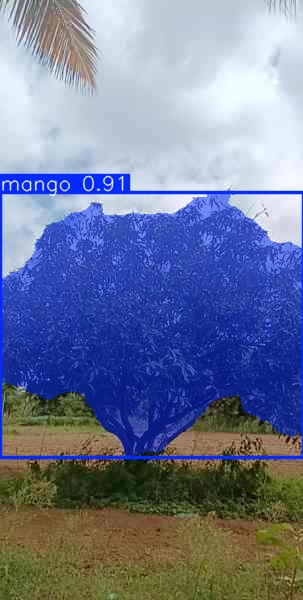

In [ ]:
from ultralytics import YOLO
from IPython.display import Image, display
import os, shutil, glob

model = YOLO('/teamspace/studios/this_studio/best_final.pt')

# ← Replace with your chosen image filename!
IMG = 'raw_images/mango/f1e81ac5-ed7a-4d9b-b6ea-5d807c25ca24.jpg'

if os.path.exists('/teamspace/studios/this_studio/inference/fresh'):
    shutil.rmtree('/teamspace/studios/this_studio/inference/fresh')

results = model.predict(
    source=IMG,
    save=True,
    conf=0.5,
    iou=0.5,
    imgsz=800,
    project='/teamspace/studios/this_studio/inference',
    name='fresh',
)

pred = glob.glob('/teamspace/studios/this_studio/inference/fresh/*.jpg')[0]
display(Image(pred, width=600))

In [ ]:
from ultralytics import YOLO

model = YOLO('/teamspace/studios/this_studio/best_50ep.pt')

model.train(
    data='/content/dataset/data.yaml',
    epochs=30,
    imgsz=800,
    batch=4,
    device=0,
    patience=20,
    save_period=10,
    project='/content/runs',
    name='mango_tea_seg_v3',
    optimizer='AdamW',
    lr0=0.0003,
    lrf=0.000001,
    warmup_epochs=3,
    weight_decay=0.0005,
    flipud=0.3,
    fliplr=0.5,
    hsv_h=0.02,
    hsv_s=0.8,
    hsv_v=0.5,
    mosaic=1.0,
    degrees=10.0,
    translate=0.1,
    scale=0.5,
    cos_lr=True,
    exist_ok=True,
)
print('Done!')

Ultralytics 8.4.56 🚀 Python-3.10.10 torch-2.1.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/dataset/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.3, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02, hsv_s=0.8, hsv_v=0.5, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0003, lrf=1e-06, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/teamspace/studios/this_studio/best_50ep.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=mango_tea_seg_v3, nbs=64, nms=False, opset=None, optimize=False, optimizer=A

In [ ]:
from ultralytics import YOLO

model = YOLO('/content/runs/mango_tea_seg_v3/weights/best.pt')

metrics = model.val(
    data='/content/dataset/data.yaml',
    split='test',
    imgsz=800,
    batch=4,
    device=0,
)

print('\nTest Results:')
print(f'  mAP50 (Box)  : {metrics.box.map50:.4f}')
print(f'  mAP50 (Mask) : {metrics.seg.map50:.4f}')
print(f'  mAP50-95 (Mask): {metrics.seg.map:.4f}')

Ultralytics 8.4.56 🚀 Python-3.10.10 torch-2.1.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLOv8l-seg summary (fused): 126 layers, 45,913,430 parameters, 0 gradients, 210.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 75.6±36.7 MB/s, size: 86.7 KB)
val: Scanning /content/dataset/labels/test... 646 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 646/646 785.8it/s 0.8s0.0s
val: New cache created: /content/dataset/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 162/162 3.7it/s 43.6s0.2ss
                   all        646       2124      0.881      0.695      0.741      0.598       0.85      0.647      0.683       0.49
                 mango        261        343      0.891      0.764      0.821      0.628      0.816      0.688      0.721      0.485
                   tea        385       1781       0.87      0.626      0.662      0.569      0.884      0.606    

In [ ]:
from ultralytics import YOLO

model = YOLO('/content/runs/mango_tea_seg_v3/weights/best.pt')

metrics = model.val(
    data='/content/dataset/data.yaml',
    split='val',
    imgsz=800,
    batch=4,
    device=0,
)

print('\nVal Results:')
print(f'  mAP50 (Box)  : {metrics.box.map50:.4f}')
print(f'  mAP50 (Mask) : {metrics.seg.map50:.4f}')
print(f'  mAP50-95 (Mask): {metrics.seg.map:.4f}')

Ultralytics 8.4.56 🚀 Python-3.10.10 torch-2.1.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLOv8l-seg summary (fused): 126 layers, 45,913,430 parameters, 0 gradients, 210.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2464.5±966.6 MB/s, size: 131.5 KB)
val: Scanning /content/dataset/labels/val.cache... 657 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 657/657 114.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 165/165 3.7it/s 44.4s0.2ss
                   all        657       2086      0.893      0.708      0.764      0.631      0.864      0.666      0.715      0.524
                 mango        261        344      0.904      0.753       0.81      0.648      0.842      0.683      0.727      0.508
                   tea        396       1742      0.882      0.664      0.717      0.615      0.885       0.65      0.703       0.54
Speed: 1.2ms preprocess, 60.5ms in


image 1/1 /teamspace/studios/this_studio/raw_images/tea/09bdebc9-69ff-460f-a9c7-51befbfa0a2a.jpg: 800x448 1 tea, 1105.9ms
Speed: 3.6ms preprocess, 1105.9ms inference, 2.5ms postprocess per image at shape (1, 3, 800, 448)
Results saved to /teamspace/studios/this_studio/inference/fresh


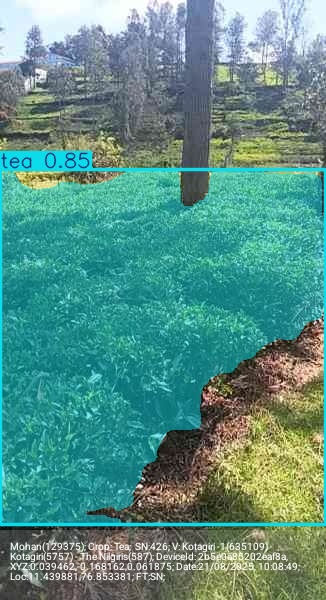

In [ ]:
from ultralytics import YOLO
from IPython.display import Image, display
import os, shutil, glob

model = YOLO('/teamspace/studios/this_studio/best_final.pt')

# ← Replace with your chosen image filename!
IMG = 'raw_images/tea/09bdebc9-69ff-460f-a9c7-51befbfa0a2a.jpg'

if os.path.exists('/teamspace/studios/this_studio/inference/fresh'):
    shutil.rmtree('/teamspace/studios/this_studio/inference/fresh')

results = model.predict(
    source=IMG,
    save=True,
    conf=0.5,
    iou=0.5,
    imgsz=800,
    project='/teamspace/studios/this_studio/inference',
    name='fresh',
)

pred = glob.glob('/teamspace/studios/this_studio/inference/fresh/*.jpg')[0]
display(Image(pred, width=600))

In [ ]:
import os
import glob
import shutil

os.makedirs('/teamspace/studios/this_studio/report_images', exist_ok=True)

# Find all png files in runs folder
for img in glob.glob('/teamspace/studios/this_studio/runs/**/*.png', recursive=True):
    print(img)

/teamspace/studios/this_studio/runs/segment/val/BoxF1_curve.png
/teamspace/studios/this_studio/runs/segment/val/BoxPR_curve.png
/teamspace/studios/this_studio/runs/segment/val/BoxP_curve.png
/teamspace/studios/this_studio/runs/segment/val/BoxR_curve.png
/teamspace/studios/this_studio/runs/segment/val/MaskF1_curve.png
/teamspace/studios/this_studio/runs/segment/val/MaskPR_curve.png
/teamspace/studios/this_studio/runs/segment/val/MaskP_curve.png
/teamspace/studios/this_studio/runs/segment/val/MaskR_curve.png
/teamspace/studios/this_studio/runs/segment/val/confusion_matrix.png
/teamspace/studios/this_studio/runs/segment/val/confusion_matrix_normalized.png
/teamspace/studios/this_studio/runs/segment/val-2/BoxF1_curve.png
/teamspace/studios/this_studio/runs/segment/val-2/BoxPR_curve.png
/teamspace/studios/this_studio/runs/segment/val-2/BoxP_curve.png
/teamspace/studios/this_studio/runs/segment/val-2/BoxR_curve.png
/teamspace/studios/this_studio/runs/segment/val-2/MaskF1_curve.png
/teamspace

In [ ]:
import shutil, os

os.makedirs('/teamspace/studios/this_studio/report_images', exist_ok=True)

images = [
    'confusion_matrix.png',
    'confusion_matrix_normalized.png',
    'MaskPR_curve.png',
    'BoxPR_curve.png',
    'MaskF1_curve.png',
    'val_batch0_pred.jpg',
    'val_batch1_pred.jpg',
]

for img in images:
    src = f'/teamspace/studios/this_studio/runs/segment/val/{img}'
    if os.path.exists(src):
        shutil.copy(src, '/teamspace/studios/this_studio/report_images/')
        print(f'✅ Copied {img}')
    else:
        print(f'❌ Not found: {img}')

✅ Copied confusion_matrix.png
✅ Copied confusion_matrix_normalized.png
✅ Copied MaskPR_curve.png
✅ Copied BoxPR_curve.png
✅ Copied MaskF1_curve.png
✅ Copied val_batch0_pred.jpg
✅ Copied val_batch1_pred.jpg
